In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Add Times New Roman to matplotlib's font manager if it's not already there
# (Colab usually has some common fonts, but this ensures it)
# This is a bit tricky as Times New Roman might not be directly available
# and typically requires installation or finding a suitable alias.
# For now, let's try to set it directly and assume a system fallback if not found.

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# Verify if the font is set (optional)
print(f"Matplotlib font family set to: {plt.rcParams['font.family']}")
print(f"Matplotlib serif font set to: {plt.rcParams['font.serif']}")

Matplotlib font family set to: ['serif']
Matplotlib serif font set to: ['Times New Roman', 'Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman', 'New Century Schoolbook', 'Century Schoolbook L', 'Utopia', 'ITC Bookman', 'Bookman', 'Nimbus Roman No9 L', 'Times New Roman', 'Times', 'Palatino', 'Charter', 'serif']


In [2]:
from google.colab import drive
import os

# Ensure the mount point is clean before attempting to mount
if os.path.isdir('/content/drive'):
    try:
        # Unmount if already mounted
        drive.flush_and_unmount()
    except ValueError: # Not mounted, proceed to clear
        pass
    # Remove any lingering files/folders in the mount point
    !rm -rf /content/drive/*

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
from pathlib import Path

DRIVE_DATA = Path("/content/drive/MyDrive/OAS2_RAW")
BASE_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local")

RAW_DIR         = BASE_DIR / "OASIS2_raw"
PREPROC_3D_DIR  = BASE_DIR / "preprocessed_3d"
SLICES_DIR      = BASE_DIR / "slices_2d"

for d in [BASE_DIR, RAW_DIR, PREPROC_3D_DIR, SLICES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLINICAL_CSV_PATH = DRIVE_DATA / "oasis_longitudinal.csv"   # your filename

# Imports & checks
import numpy as np
import pandas as pd
import nibabel as nib
import SimpleITK as sitk
from skimage.transform import resize
from PIL import Image
from tqdm import tqdm
import ants
from nilearn.datasets import load_mni152_template
import torch
import nilearn

print(f"NumPy:      {np.__version__}")
print(f"PyTorch:    {torch.__version__} | CUDA: {torch.cuda.is_available()}")
print(f"Nilearn:    {nilearn.__version__}")

mni = load_mni152_template(resolution=1)
print(f"MNI152 shape: {mni.shape}")

print("\nEnvironment ready \u2192 proceed.")

ModuleNotFoundError: No module named 'SimpleITK'

## Extraction of MRI Images.

In [ ]:
# %% Cell 1: Locate, Extract & Verify OASIS-2 Raw Data (Analyze format support)
import tarfile
from pathlib import Path
from tqdm import tqdm

print("=== Cell 1: Extracting & Verifying OASIS-2 Raw Files (Analyze .img/.hdr) ===")

# ────────────────────────────────────────────────────────────────
# Paths
DRIVE_SOURCE = Path("/content/drive/MyDrive/OAS2_RAW")

tar_files = [
    DRIVE_SOURCE / "OAS2_RAW_PART1.tar.gz",
    DRIVE_SOURCE / "OAS2_RAW_PART2.tar.gz"
]

# Fast local working directory
RAW_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local/OASIS2_raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

# ────────────────────────────────────────────────────────────────
# Extract both parts if needed
extracted_any = False

for tar_path in tar_files:
    if not tar_path.is_file():
        print(f"✗ Not found: {tar_path.name}")
        continue

    print(f"→ Found: {tar_path.name}")

    # Very rough check: if we already have subject folders
    if list(RAW_DIR.glob("OAS2_*")):
        print("  → subject folders already exist → skipping extraction")
        continue

    print(f"  → extracting {tar_path.name} ... (may take 5–15 min total)")

    try:
        with tarfile.open(tar_path, "r:gz") as tar:
            members = tar.getmembers()
            for member in tqdm(members, desc=f"Extracting {tar_path.name}", unit="file"):
                tar.extract(member, path=RAW_DIR)
        print(f"  ✓ Successfully extracted {tar_path.name}")
        extracted_any = True
    except Exception as e:
        print(f"  ✗ Extraction error: {e}")
        continue

# ────────────────────────────────────────────────────────────────
# After extraction: detect actual MRI files (Analyze format)
print("\nScanning extracted content for MRI data...")

# Look for .img files (the image data files in Analyze format)
img_files = sorted(RAW_DIR.rglob("*.img"))

print(f"Total .img files found: {len(img_files):,d}")

if img_files:
    print("\nExamples of found files (first 8):")
    for p in img_files[:8]:
        rel = p.relative_to(RAW_DIR)
        print(f"  {rel}")

    # Show top-level structure
    top_level = set(p.relative_to(RAW_DIR).parts[0] for p in img_files if len(p.relative_to(RAW_DIR).parts) > 1)
    print(f"\nNumber of top-level subject folders: {len(top_level)}")
    print(f"Examples: {', '.join(sorted(top_level)[:6])} ...")

    # Count sessions roughly
    sessions = set()
    for p in img_files:
        parts = p.relative_to(RAW_DIR).parts
        if len(parts) >= 2:
            sessions.add(parts[0] + "/" + parts[1])
    print(f"Approximate number of imaging sessions: {len(sessions):,d}")
else:
    print("\nNo .img files found after extraction.")
    print("Possible issues and next steps:")
    print("  1. Run this diagnostic command in a new cell:")
    print("     !ls -lR \"{RAW_DIR}\" | head -n 40")
    print("  2. Check if tar.gz files are corrupted → re-download from official OASIS site")
    print("  3. Confirm the tar files actually contain Analyze format data")

print("\n" + "="*60)
print("Next steps:")
if len(img_files) > 50:
    print("→ Looks good! Ready to move to Cell 2 (clinical data loading)")
    print("→ In later cells we will convert .img/.hdr → .nii.gz")
else:
    print("→ Issue detected. Do NOT proceed yet.")
    print("  Please paste the output above + run the !ls command if needed.")


'\nimport tarfile\nfrom pathlib import Path\nfrom tqdm import tqdm\n\nprint("=== Cell 1: Extracting & Verifying OASIS-2 Raw Files (Analyze .img/.hdr) ===")\n\n# ────────────────────────────────────────────────────────────────\n# Paths\nDRIVE_SOURCE = Path("/content/drive/MyDrive/OAS2_RAW")\n\ntar_files = [\n    DRIVE_SOURCE / "OAS2_RAW_PART1.tar.gz",\n    DRIVE_SOURCE / "OAS2_RAW_PART2.tar.gz"\n]\n\n# Fast local working directory\nRAW_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local/OASIS2_raw")\nRAW_DIR.mkdir(parents=True, exist_ok=True)\n\n# ────────────────────────────────────────────────────────────────\n# Extract both parts if needed\nextracted_any = False\n\nfor tar_path in tar_files:\n    if not tar_path.is_file():\n        print(f"✗ Not found: {tar_path.name}")\n        continue\n\n    print(f"→ Found: {tar_path.name}")\n\n    # Very rough check: if we already have subject folders\n    if list(RAW_DIR.glob("OAS2_*")):\n        print("  → subject folders already exist → s

Plotting Extracted Analysis Ready MRI(.img & .hdr) file

Searching for AD and CN patient MRI files...
  Found CN patient file: mpr-1.nifti.img (MRI ID: OAS2_0001_MR1)
  Found AD patient file: mpr-1.nifti.img (MRI ID: OAS2_0007_MR3)

Loading and plotting AD Patient slices from: mpr-1.nifti.img

Loading and plotting CN Patient slices from: mpr-1.nifti.img


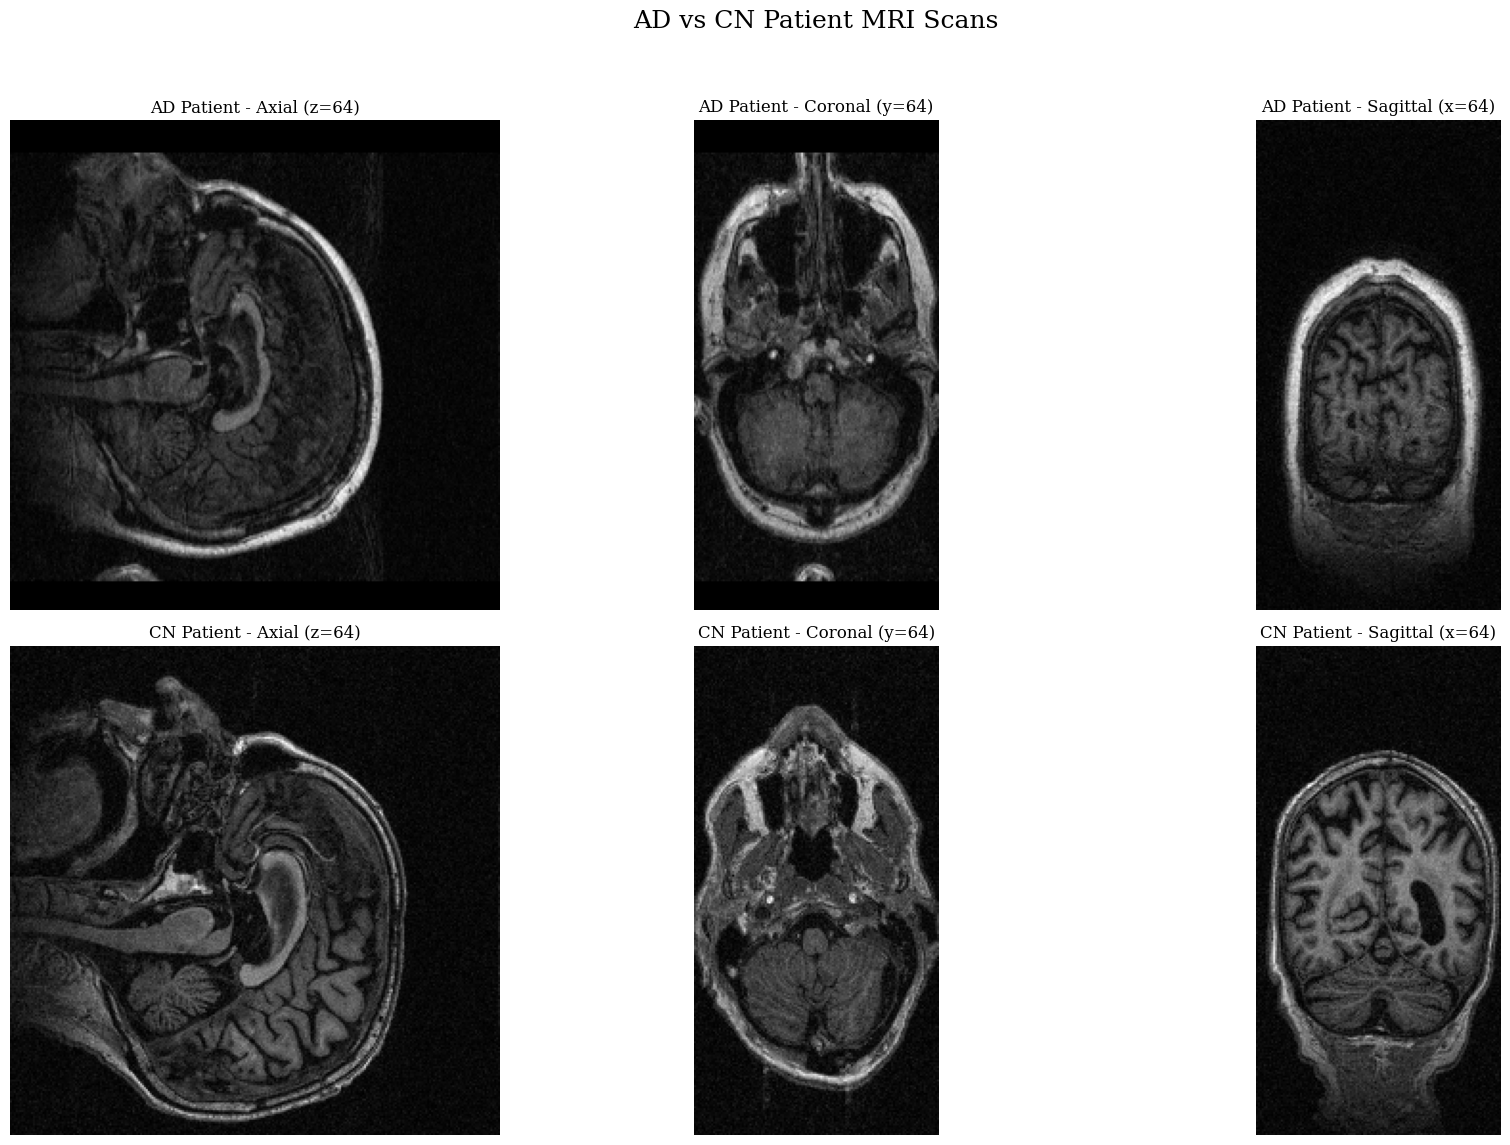

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd # Added import for clinical data handling

# --- Start of code to define mri_to_label (copied from Cell 2: jjw05aTz-iAX) ---
# Path to your clinical CSV (from previous setup)
CLINICAL_CSV_PATH = Path("/content/drive/MyDrive/OAS2_RAW/oasis_longitudinal.csv")

mri_to_label = {}
if not CLINICAL_CSV_PATH.exists():
    print(f"Warning: Clinical CSV not found at: {CLINICAL_CSV_PATH}. Cannot create mri_to_label mapping.")
else:
    df = pd.read_csv(CLINICAL_CSV_PATH)

    # Create label mapping: MRI ID → class
    def cdr_to_class(cdr):
        if pd.isna(cdr):
            return None
        if cdr == 0.0:
            return "CN"
        elif cdr == 0.5:
            return "MCI"
        else:  # >=1
            return "AD"

    df['class_label'] = df['CDR'].apply(cdr_to_class)
    df['MRI ID'] = df['MRI ID'].astype(str).str.strip()

    mri_to_label = df.set_index('MRI ID')['class_label'].to_dict()
    mri_to_label = {k: v for k, v in mri_to_label.items() if v is not None}
    # --- End of code to define mri_to_label ---


# Assuming RAW_DIR and mri_to_label are available from previous cells
# If RAW_DIR is not defined, please ensure Cell 0 (or a cell defining it) has been run.
# If mri_to_label is not defined, please ensure Cell 2 has been run.

RAW_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local/OASIS2_raw")

print("Searching for AD and CN patient MRI files...")

ad_file = None
cn_file = None

# Iterate through all .img files to find one AD and one CN
for img_path in sorted(RAW_DIR.rglob("*.img")):
    # Extract MRI ID from path (example: OAS2_0001_MR1 from .../OAS2_0001_MR1/...)
    parts = img_path.parts
    mri_id_found = None
    for part in parts:
        if "OAS2_" in part and "_MR" in part:
            mri_id_found = part
            break

    if mri_id_found and mri_id_found in mri_to_label:
        label = mri_to_label[mri_id_found]
        if label == "AD" and ad_file is None:
            ad_file = img_path
            print(f"  Found AD patient file: {ad_file.name} (MRI ID: {mri_id_found})")
        elif label == "CN" and cn_file is None:
            cn_file = img_path
            print(f"  Found CN patient file: {cn_file.name} (MRI ID: {mri_id_found})")

    if ad_file and cn_file:
        break

if not ad_file:
    print("Warning: Could not find an AD patient MRI file with a valid label.")
if not cn_file:
    print("Warning: Could not find a CN patient MRI file with a valid label.")

# Define the specific slices to extract
specified_slices = {"x": 64, "y": 64, "z": 64}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("AD vs CN Patient MRI Scans", fontsize=18)

def plot_patient_slices(ax_row, patient_file, title_prefix):
    if patient_file is None:
        for ax in ax_row:
            ax.text(0.5, 0.5, f"{title_prefix} File Not Found", ha='center', va='center', fontsize=12)
            ax.axis('off')
        return

    print(f"\nLoading and plotting {title_prefix} slices from: {patient_file.name}")
    mri = nib.load(str(patient_file))
    mri_data = mri.get_fdata().squeeze()

    dx, dy, dz = mri_data.shape

    # Plot Axial Slice (Z-axis)
    z_slice = min(specified_slices["z"], dz - 1) # Ensure slice index is within bounds
    ax_row[0].imshow(mri_data[:, :, z_slice], cmap='gray', origin='lower')
    ax_row[0].set_title(f"{title_prefix} - Axial (z={z_slice})")
    ax_row[0].axis('off')

    # Plot Coronal Slice (Y-axis)
    y_slice = min(specified_slices["y"], dy - 1)
    ax_row[1].imshow(mri_data[:, y_slice, :], cmap='gray', origin='lower')
    ax_row[1].set_title(f"{title_prefix} - Coronal (y={y_slice})")
    ax_row[1].axis('off')

    # Plot Sagittal Slice (X-axis)
    x_slice = min(specified_slices["x"], dx - 1)
    ax_row[2].imshow(mri_data[x_slice, :, :], cmap='gray', origin='lower')
    ax_row[2].set_title(f"{title_prefix} - Sagittal (x={x_slice})")
    ax_row[2].axis('off')

# Plot AD patient slices
plot_patient_slices(axes[0], ad_file, "AD Patient")

# Plot CN patient slices
plot_patient_slices(axes[1], cn_file, "CN Patient")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

# Define the path to save the PDF file in your Google Drive
save_path = Path("/content/drive/MyDrive/OASIS2_Project_local/AD_vs_CN_MRI_Comparison.pdf")

# Ensure the parent directory exists (it should, from previous cells)
save_path.parent.mkdir(parents=True, exist_ok=True)

# Save the last active figure to PDF
plt.savefig(save_path, format='pdf')

print(f"The comparison plot has been saved as a PDF vector file at: {save_path}")

The comparison plot has been saved as a PDF vector file at: /content/drive/MyDrive/OASIS2_Project_local/AD_vs_CN_MRI_Comparison.pdf


<Figure size 640x480 with 0 Axes>

## Conversion (If necessary)

In [ ]:
# %% Cell 1.5: Convert Analyze (.img/.hdr) pairs to NIfTI (.nii.gz)

print("=== Cell 1.5: Converting Analyze to NIfTI ===")

import nibabel as nib
from pathlib import Path
from tqdm import tqdm

# Input: raw Analyze files
# Output: converted NIfTI in same sub-folders (or a new one if preferred)
CONVERTED_DIR = RAW_DIR.parent / "converted_nii"  # e.g., /content/OASIS2_Project_local/converted_nii
CONVERTED_DIR.mkdir(parents=True, exist_ok=True)

img_files = sorted(RAW_DIR.rglob("*.img"))
S
print(f"Found {len(img_files)} .img files to convert")

converted_count = 0
skipped_count = 0

for img_path in tqdm(img_files, desc="Converting to NIfTI"):
    hdr_path = img_path.with_suffix(".hdr")

    if not hdr_path.exists():
        print(f"  Warning: No matching .hdr for {img_path.name} → skipping")
        skipped_count += 1
        continue

    # Optional: skip if already converted (check for .nii.gz sibling)
    nii_path = CONVERTED_DIR / img_path.relative_to(RAW_DIR).with_suffix(".nii.gz")
    nii_path.parent.mkdir(parents=True, exist_ok=True)

    if nii_path.exists():
        # print(f"  Already converted: {nii_path.name}")
        skipped_count += 1
        continue

    try:
        # Load Analyze pair
        img = nib.load(str(img_path))

        # Save as compressed NIfTI-1 (default orientation preserved)
        nib.save(img, str(nii_path))

        converted_count += 1

        # Optional: quick sanity check (uncomment for first few)
        # print(f"  Converted: {nii_path.relative_to(CONVERTED_DIR)} | shape={img.shape}")

    except Exception as e:
        print(f"  Error converting {img_path.name}: {e}")
        skipped_count += 1

print("\nConversion Summary:")
print(f"  Successfully converted: {converted_count}")
print(f"  Skipped (already exist or missing hdr): {skipped_count}")
print(f"  Total .nii.gz now available: {len(list(CONVERTED_DIR.rglob('*.nii.gz'))):,d}")

if converted_count > 0:
    print("\nExamples of converted files:")
    for p in list(CONVERTED_DIR.rglob("*.nii.gz"))[:5]:
        print(f"  {p.relative_to(CONVERTED_DIR)}")

print("\nNext: Update later cells to use CONVERTED_DIR instead of RAW_DIR for mri_files.")
print("   → Ready for Cell 2 (clinical loading)")

SyntaxError: incomplete input (1352114383.py, line 2)

## Load Clinical Data & Create CN / MCI / AD Mapping

In [4]:
print("=== Cell 2: Loading OASIS-2 Clinical Metadata ===")

import pandas as pd
from pathlib import Path

# Path to your CSV (from Cell 0)
CLINICAL_CSV_PATH = "/content/drive/MyDrive/OAS2_RAW/oasis_longitudinal.csv"

if not Path(CLINICAL_CSV_PATH).exists():
    raise FileNotFoundError(f"CSV not found at: {CLINICAL_CSV_PATH}\nCheck filename/path.")

df = pd.read_csv(CLINICAL_CSV_PATH)

print(f"CSV loaded — {len(df)} rows (sessions), {df['Subject ID'].nunique()} unique subjects")

# Show available columns (important for debugging)
print("\nColumns in CSV:")
print(df.columns.tolist())

# Required columns check
required = ['MRI ID', 'CDR']
missing = [col for col in required if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}\nAvailable: {df.columns.tolist()}")

# Create label mapping: MRI ID → class
# CDR logic: 0 → CN, 0.5 → MCI, 1/2/3 → AD (some use 0.5 as questionable/very mild AD)
def cdr_to_class(cdr):
    if pd.isna(cdr):
        return None
    if cdr == 0.0:
        return "CN"
    elif cdr == 0.5:
        return "MCI"
    else:  # >=1
        return "AD"

df['class_label'] = df['CDR'].apply(cdr_to_class)

# Clean MRI ID (remove any extra spaces)
df['MRI ID'] = df['MRI ID'].astype(str).str.strip()

# Dictionary: MRI_ID → label
mri_to_label = df.set_index('MRI ID')['class_label'].to_dict()

# Remove None values (sessions without CDR)
mri_to_label = {k: v for k, v in mri_to_label.items() if v is not None}

print("\nLabel Distribution:")
print(df['class_label'].value_counts(dropna=False))

print(f"\nTotal sessions with valid label: {len(mri_to_label)}")

# Quick preview of mapping
print("\nExample mappings (first 5):")
for mid, lbl in list(mri_to_label.items())[:5]:
    print(f"  {mid} → {lbl}")

print("\nNext: In Cell 3 we will define preprocessing functions.")
print("   → Then in Cell 4 we will use CONVERTED_DIR for input scans.")

=== Cell 2: Loading OASIS-2 Clinical Metadata ===
CSV loaded — 373 rows (sessions), 150 unique subjects

Columns in CSV:
['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']

Label Distribution:
class_label
CN     206
MCI    123
AD      44
Name: count, dtype: int64

Total sessions with valid label: 373

Example mappings (first 5):
  OAS2_0001_MR1 → CN
  OAS2_0001_MR2 → CN
  OAS2_0002_MR1 → MCI
  OAS2_0002_MR2 → MCI
  OAS2_0002_MR3 → MCI

Next: In Cell 3 we will define preprocessing functions.
   → Then in Cell 4 we will use CONVERTED_DIR for input scans.


## **3D Preprocessing**

**3D Preprocessing Functions:**

(RAS+ → HD-BET → N4 → MNI152)

In [ ]:
print("=== Cell 3: Defining Preprocessing Pipeline Functions ===")

import nibabel as nib
import SimpleITK as sitk
import ants
from pathlib import Path
from tqdm import tqdm
import subprocess
import shutil
import torch

# Import the MNI loader
from nilearn.datasets import load_mni152_template


CONVERTED_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local/converted_nii")
PREPROC_3D_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local/preprocessed_3d")
PREPROC_3D_DIR.mkdir(parents=True, exist_ok=True)

# MNI152 template
mni_template_path = Path("/content/drive/MyDrive/OASIS2_Project_local/mni152_template_1mm.nii.gz")
if not mni_template_path.exists():
    print("Downloading MNI152 1mm template...")
    try:
        mni_img = load_mni152_template(resolution=1)
        nib.save(mni_img, str(mni_template_path))
        print("MNI template saved successfully.")
    except Exception as e:
        print(f"Error downloading/saving MNI template: {e}")
        print("Fallback: You can manually download from https://templateflow.org and upload to /content/")
        raise


# Reorient to closest canonical (RAS+)
def reorient_to_ras(input_path: Path, output_path: Path):
    img = nib.load(str(input_path))
    reoriented_img = nib.as_closest_canonical(img)
    nib.save(reoriented_img, str(output_path))
    return output_path


# N4 Bias Field Correction
def n4_bias_correction(input_path: Path, output_path: Path):
    print(f"Applying N4 bias correction to {input_path.name}...")
    img = sitk.ReadImage(str(input_path))

    # Otsu-based brain mask (robust post-skull-strip)
    mask = sitk.OtsuThreshold(img, 0, 1, 200)

    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrected = corrector.Execute(img, mask)

    sitk.WriteImage(corrected, str(output_path))
    return output_path


# Affine registration to MNI152
def register_to_mni152(input_path: Path, output_path: Path):
    print(f"Registering {input_path.name} to MNI152 (Affine)...")
    fixed = ants.image_read(str(mni_template_path))
    moving = ants.image_read(str(input_path))

    reg = ants.registration(
        fixed=fixed,
        moving=moving,
        type_of_transform="Affine",   # fast & sufficient for hippocampus alignment
        verbose=False
    )

    warped = reg["warpedmovout"]
    ants.image_write(warped, str(output_path))
    return output_path

print("\nAll preprocessing functions defined successfully.")
print("   - Reorient: nibabel canonical")
print("   - Skull strip: HD-BET (GPU if available)")
print("   - Bias corr: N4ITK")
print("   - Registration: ANTs Affine → MNI152 1mm")
print("\nNext: Cell 4 – Run on a small test batch (3–5 scans recommended first)")

=== Cell 3: Defining Preprocessing Pipeline Functions ===

All preprocessing functions defined successfully.
   - Reorient: nibabel canonical
   - Skull strip: HD-BET (GPU if available)
   - Bias corr: N4ITK
   - Registration: ANTs Affine → MNI152 1mm

Next: Cell 4 – Run on a small test batch (3–5 scans recommended first)


Function for Skull stripping with HD-BET

In [ ]:
def skull_strip_hd_bet(input_path: Path, output_dir: Path):
    output_dir.mkdir(exist_ok=True)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Running HD-BET on {input_path.name} using device: {device}...")

    # IMPORTANT: output MUST be a FILE name when input is a file
    output_filename = output_dir / f"{input_path.stem}_bet.nii.gz"

    cmd = [
        "hd-bet",
        "-i", str(input_path),
        "-o", str(output_filename),     # ← now a file, not directory
        "-device", device,
        "--disable_tta"
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print("HD-BET stdout:")
        print(result.stdout)
        print("\nHD-BET stderr:")
        print(result.stderr)
        raise RuntimeError(f"HD-BET failed with code {result.returncode}")

    if not output_filename.exists():
        raise FileNotFoundError(f"HD-BET did not produce expected output: {output_filename}")

    return output_filename

Testing 3D Preprocessing functions that i created on some MRI scans

In [ ]:
# %% Cell 4: Run Preprocessing Pipeline – Small Test Batch First (Per-File Lock)

print("=== Cell 4: Running Preprocessing Pipeline (Test Batch) ===")

import time
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

# ────────────────────────────────────────────────────────────────
# Configuration
MAX_SCANS_TO_PROCESS = 772          # adjust freely
SKIP_IF_ALREADY_DONE = True

CONVERTED_DIR  = Path("/content/drive/MyDrive/OASIS2_Project_local/converted_nii")
PREPROC_3D_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local/preprocessed_3d")
PREPROC_3D_DIR.mkdir(parents=True, exist_ok=True)

# ────────────────────────────────────────────────────────────────
# Collect all acquisition files grouped by MRI ID
print("Collecting labeled scans...")

session_to_files = defaultdict(list)

for p in sorted(CONVERTED_DIR.rglob("*.nii*")):
    parts = p.relative_to(CONVERTED_DIR).parts
    mri_id = None
    for part in reversed(parts[:-1]):
        if "_MR" in part:
            mri_id = part.strip()
            break

    if mri_id and mri_id in mri_to_label:
        session_to_files[mri_id].append(p)

all_sessions = []
for mri_id, files in session_to_files.items():
    label = mri_to_label[mri_id]
    all_sessions.append((mri_id, label, files))

print(f"Found {len(all_sessions)} unique sessions")
print(f"  → {sum(len(f) for _,_,f in all_sessions)} acquisition files total")

# Flatten to individual files
labeled_scans = []
for mri_id, label, files in all_sessions:
    for file_path in files:
        labeled_scans.append((file_path, mri_id, label))

print(f"→ Total individual files to consider: {len(labeled_scans)}")

test_batch = labeled_scans[:MAX_SCANS_TO_PROCESS]

print(f"\nWill process first {len(test_batch)} acquisition files:")
for i, (p, mid, lbl) in enumerate(test_batch, 1):
    print(f"  {i:3d}. {mid} – {p.name} → {lbl}")

# ────────────────────────────────────────────────────────────────
success_count = 0
failed = []

for scan_path, mri_id, label in tqdm(test_batch, desc="Preprocessing batch"):
    start_time = time.time()

    # === PER-FILE LOCK (recommended for max diversity) ===
    acq_name = scan_path.stem  # e.g. "mpr-1.nifti.nii"
    lock_file = PREPROC_3D_DIR / f"{mri_id}_{acq_name}.lock"

    if SKIP_IF_ALREADY_DONE and lock_file.exists():
        print(f"  {mri_id} – {acq_name} already processed (lock exists) → skipping")
        success_count += 1
        continue

    try:
        # Use acquisition name in final filename to avoid overwrite
        final_path = PREPROC_3D_DIR / f"{mri_id}_{acq_name}_preproc_final.nii.gz"

        reor_path   = PREPROC_3D_DIR / f"{mri_id}_{acq_name}_reor.nii.gz"
        bet_dir     = PREPROC_3D_DIR / f"bet_{mri_id}_{acq_name}"
        bet_path    = PREPROC_3D_DIR / f"{mri_id}_{acq_name}_bet.nii.gz"
        bias_path   = PREPROC_3D_DIR / f"{mri_id}_{acq_name}_bias_corrected.nii.gz"

        reorient_to_ras(scan_path, reor_path)
        stripped = skull_strip_hd_bet(reor_path, bet_dir)
        shutil.move(str(stripped), str(bet_path))
        n4_bias_correction(bet_path, bias_path)
        register_to_mni152(bias_path, final_path)

        # Cleanup
        for temp in [reor_path, bet_path, bias_path]:
            if temp.exists():
                temp.unlink(missing_ok=True)
        shutil.rmtree(bet_dir, ignore_errors=True)

        elapsed = time.time() - start_time
        print(f"  ✓ Success: {mri_id} – {acq_name} ({label}) in {elapsed:.1f} seconds")
        success_count += 1

        # Create per-file lock only after full success
        lock_file.write_text(f"done on {time.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"  → Lock file created: {lock_file.name}")

    except Exception as e:
        elapsed = time.time() - start_time
        msg = f"{type(e).__name__}: {str(e)}"
        print(f"  ✗ Failed: {mri_id} – {acq_name} after {elapsed:.1f}s → {msg}")
        failed.append((mri_id, acq_name, msg))

# ────────────────────────────────────────────────────────────────
print("\n" + "═"*70)
print(f"Success: {success_count}/{len(test_batch)} files")
if failed:
    print("Failures:")
    for mid, acq, err in failed:
        print(f"  {mid} – {acq} → {err}")

print(f"\nFiles saved in: {PREPROC_3D_DIR}")
print("Each acquisition now has its own lock file.")
print("Next run will skip only already-successful acquisitions.")

## 3D Preprocessing Operations Visualization

In [5]:
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn import plotting
from pathlib import Path
import shutil

# Configuration
example_mri_id = "OAS2_0002_MR1"  # An example MRI ID that was successfully processed
example_acq_name = "mpr-2.nifti.nii" # The acquisition name from the example_mri_id

# Re-use paths from previous cells
CONVERTED_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local/converted_nii")

# Temporary directory for visualization files
temp_viz_dir = Path("/tmp/viz_preprocessing_steps")
if temp_viz_dir.exists():
    shutil.rmtree(temp_viz_dir)
temp_viz_dir.mkdir(parents=True, exist_ok=True)

print(f"Temporary directory for visualization: {temp_viz_dir}")

# Attempt to find the original converted NIfTI file for the example_mri_id
original_converted_path = None
# This loop tries to find the specific file. Adjust if your folder structure differs.
for p in CONVERTED_DIR.rglob(f"*{example_mri_id}*.nii.gz"):
    if example_acq_name in p.name:
        original_converted_path = p
        break

if original_converted_path is None:
    # Fallback if the specific name isn't found, pick any for the example_mri_id
    potential_originals = list(CONVERTED_DIR.rglob(f"*{example_mri_id}*.nii.gz"))
    if potential_originals:
        original_converted_path = potential_originals[0]
        print(f"Warning: Specific acquisition '{example_acq_name}' not found for '{example_mri_id}'. Using: {original_converted_path.name}")
    else:
        raise FileNotFoundError(f"Could not find any converted NIfTI for {example_mri_id} in {CONVERTED_DIR}. Please ensure files exist.")

print(f"Using example original NIfTI: {original_converted_path.relative_to(CONVERTED_DIR.parent)}")

def plot_mri_step(image_path, title):
    img = nib.load(str(image_path))
    fig = plt.figure(figsize=(10, 5))
    plotting.plot_anat(img, title=title, cut_coords=(0, 0, 0), display_mode='ortho', figure=fig)
    plt.show()

ModuleNotFoundError: No module named 'nilearn'

### 1. Original Converted NIfTI

In [6]:
print(f"Displaying: {original_converted_path.name}")
plot_mri_step(original_converted_path, "Original Converted NIfTI")

NameError: name 'original_converted_path' is not defined

### 2. Reorientation to RAS+ Canonical

In [4]:
reor_output_path = temp_viz_dir / f"{original_converted_path.stem}_reor.nii.gz"
print(f"Applying reorientation to {original_converted_path.name}...")
reorient_to_ras(original_converted_path, reor_output_path)
plot_mri_step(reor_output_path, "After Reorientation (RAS+)")

NameError: name 'temp_viz_dir' is not defined

### 3. Skull Stripping (HD-BET)

In [5]:
bet_output_path = temp_viz_dir / f"{original_converted_path.stem}_bet.nii.gz"
print(f"Applying HD-BET to {reor_output_path.name}...")
# The skull_strip_hd_bet function expects an output directory for temporary files it might create
# but returns the path to the actual skull-stripped file.
# We will call it with `temp_viz_dir` as the output_dir, and then rename/move the output.

# Create a sub-directory for HD-BET's output to prevent clutter
hd_bet_temp_dir = temp_viz_dir / "hd_bet_output"
hd_bet_temp_dir.mkdir(exist_ok=True)

# The skull_strip_hd_bet function expects the input and output to be files. It writes to output_filename.
skull_stripped_temp = skull_strip_hd_bet(reor_output_path, hd_bet_temp_dir)

# HD-BET will name the output file something like input_bet.nii.gz in the output_dir provided
# We need to find the actual output file from `hd_bet_temp_dir`
# Based on the skull_strip_hd_bet function, `output_filename` is `output_dir / f"{input_path.stem}_bet.nii.gz"`
# So the expected file is `hd_bet_temp_dir / f"{reor_output_path.stem}_bet.nii.gz"`

expected_hd_bet_file = hd_bet_temp_dir / f"{reor_output_path.stem}_bet.nii.gz"

if expected_hd_bet_file.exists():
    shutil.copy(expected_hd_bet_file, bet_output_path)
    plot_mri_step(bet_output_path, "After Skull Stripping (HD-BET)")
else:
    print(f"Error: HD-BET output not found at {expected_hd_bet_file}")

# Clean up the temporary HD-BET directory
shutil.rmtree(hd_bet_temp_dir, ignore_errors=True)


NameError: name 'temp_viz_dir' is not defined

### 4. N4 Bias Field Correction

In [6]:
bias_corr_output_path = temp_viz_dir / f"{original_converted_path.stem}_n4_bias_corr.nii.gz"
print(f"Applying N4 bias correction to {bet_output_path.name}...")
n4_bias_correction(bet_output_path, bias_corr_output_path)
plot_mri_step(bias_corr_output_path, "After N4 Bias Field Correction")

NameError: name 'temp_viz_dir' is not defined

### 5. Affine Registration to MNI152 Template

In [7]:
mni_reg_output_path = temp_viz_dir / f"{original_converted_path.stem}_mni_reg.nii.gz"
print(f"Applying affine registration to MNI152 for {bias_corr_output_path.name}...")
register_to_mni152(bias_corr_output_path, mni_reg_output_path)
plot_mri_step(mni_reg_output_path, "After Affine Registration to MNI152")

NameError: name 'temp_viz_dir' is not defined

Shape of preprocessed volume: (197, 233, 189)


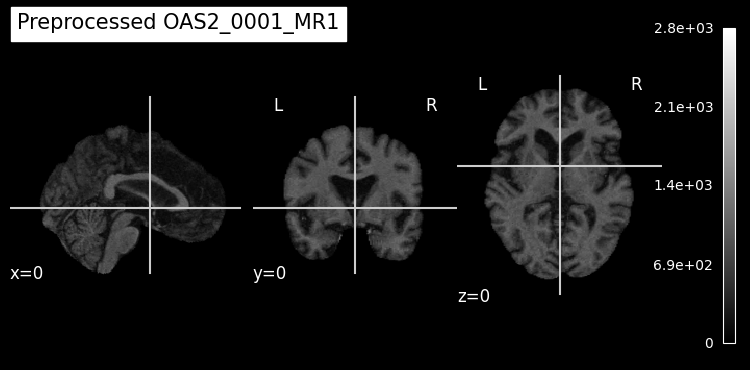

In [ ]:
# Quick visual check of one preprocessed file
from nilearn import plotting
import nibabel as nib

example_file = "/content/drive/MyDrive/OASIS2_Project_local/preprocessed_3d/OAS2_0002_MR1_mpr-1.nifti.nii_preproc_final.nii.gz"
img = nib.load(example_file)

print("Shape of preprocessed volume:", img.shape)
plotting.plot_anat(img, title="Preprocessed OAS2_0001_MR1", cut_coords=(0,0,0), display_mode='ortho')
plotting.show()

Creating visualization for: OAS2_0001_MR1
✓ Preprocessed Found: OAS2_0001_MR1_mpr-1.nifti.nii_preproc_final.nii.gz


/tmp/ipykernel_12295/3614212823.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


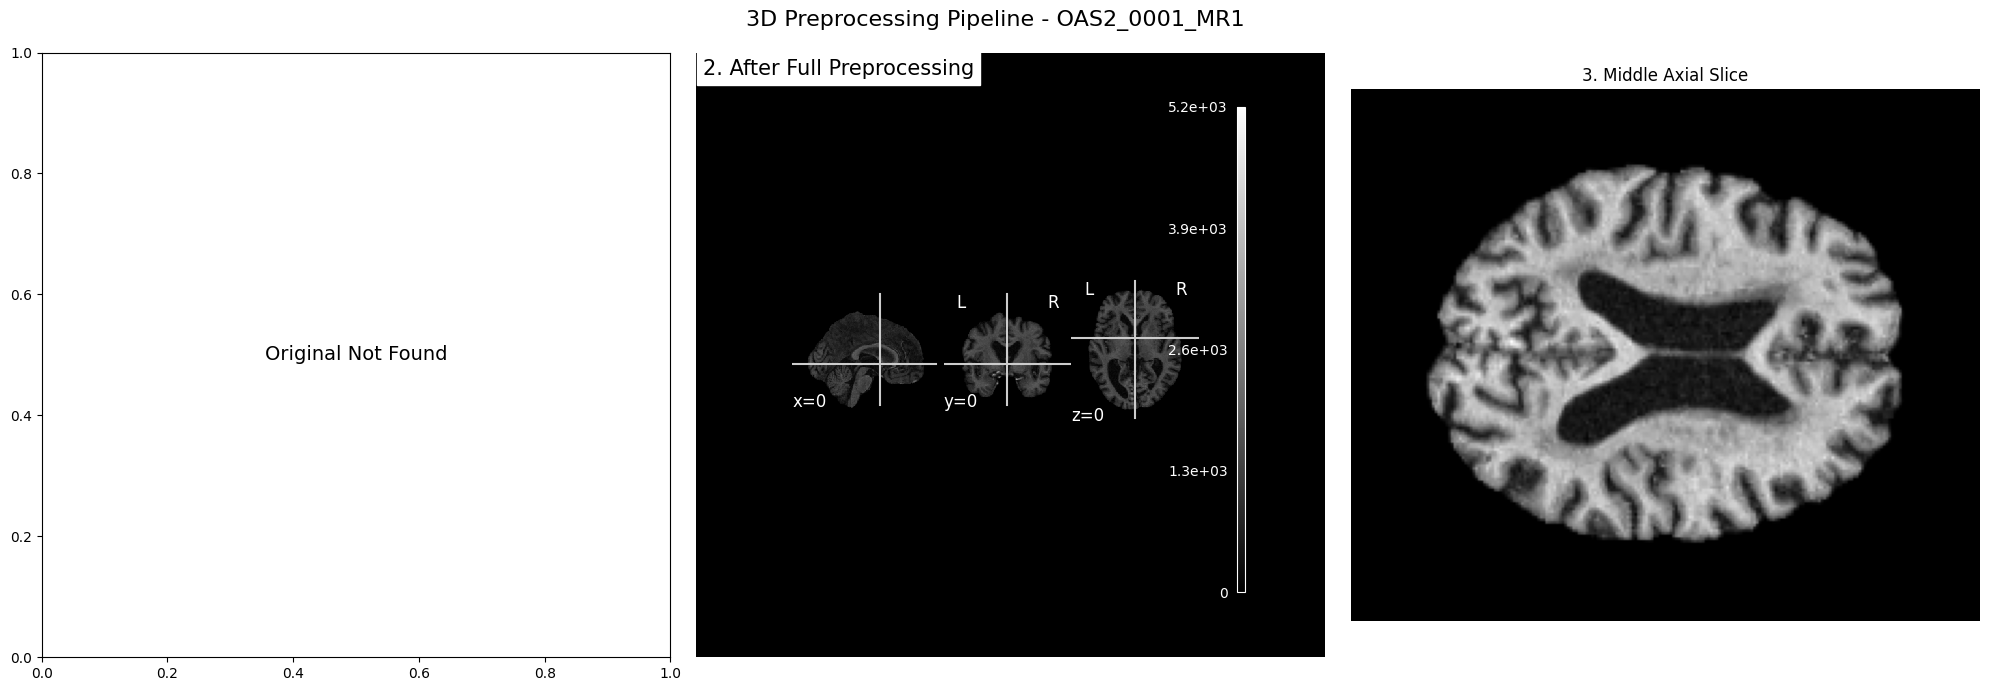

In [ ]:
# %% Robust Visualization - Auto Search for Files

import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting
from pathlib import Path

example_id = "OAS2_0001_MR1"   # Change this to any subject you want

print(f"Creating visualization for: {example_id}")

base = Path("/content/drive/MyDrive/OASIS2_Project_local")

# Auto search for original file
original_files = list(base.glob(f"converted_nii/**/{example_id}*.nii.gz"))
preproc_files = list(base.glob(f"preprocessed_3d/{example_id}*preproc_final.nii.gz"))

original_path = original_files[0] if original_files else None
preproc_path = preproc_files[0] if preproc_files else None

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# 1. Original
if original_path and original_path.exists():
    img1 = nib.load(str(original_path))
    plotting.plot_anat(img1, axes=axes[0], title="1. Original MRI", display_mode='ortho', cut_coords=(0,0,0))
    print(f"✓ Original Found: {original_path.name}")
else:
    axes[0].text(0.5, 0.5, "Original Not Found", ha='center', va='center', fontsize=14)

# 2. Preprocessed
if preproc_path and preproc_path.exists():
    img2 = nib.load(str(preproc_path))
    plotting.plot_anat(img2, axes=axes[1], title="2. After Full Preprocessing", display_mode='ortho', cut_coords=(0,0,0))
    print(f"✓ Preprocessed Found: {preproc_path.name}")
else:
    axes[1].text(0.5, 0.5, "Preprocessed Not Found", ha='center', va='center', fontsize=14)

# 3. Middle Slice
if preproc_path and preproc_path.exists():
    data = img2.get_fdata()
    mid = data.shape[2] // 2
    axes[2].imshow(data[:, :, mid], cmap='gray', origin='lower')
    axes[2].set_title("3. Middle Axial Slice")
    axes[2].axis('off')
else:
    axes[2].text(0.5, 0.5, "No Slice Available", ha='center', va='center', fontsize=14)

plt.suptitle(f"3D Preprocessing Pipeline - {example_id}", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# %% Cell 5: Extracting 2D Axial Slices – Safe for empty/deleted metadata

print("=== Cell 5: Extracting 2D Axial Slices from Preprocessed Volumes ===")

import numpy as np
import nibabel as nib
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from skimage.transform import resize
from PIL import Image

# Folders
PREPROC_3D_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local/preprocessed_3d")
SLICES_DIR     = Path("/content/drive/MyDrive/OASIS2_Project_local/slices_2d")
SLICES_DIR.mkdir(parents=True, exist_ok=True)

METADATA_CSV   = SLICES_DIR.parent / "oasis2_slices_metadata.csv"

SLICE_START_PCT = 0.40
SLICE_END_PCT   = 0.60
TARGET_SIZE     = (224, 224)

# ────────────────────────────────────────────────────────────────
print("Checking existing metadata...")
if METADATA_CSV.exists():
    existing_df = pd.read_csv(METADATA_CSV)
    print(f"Loaded {len(existing_df)} previous entries")
else:
    existing_df = pd.DataFrame()
    print("No metadata CSV → starting fresh")

# Only try to use existing paths if the DataFrame has the column
if not existing_df.empty and "npy_path" in existing_df.columns:
    existing_npy = set(existing_df["npy_path"].astype(str))
    print(f"Found {len(existing_npy)} existing slices on record")
else:
    existing_npy = set()
    print("No previous slices recorded (or CSV empty)")

# ────────────────────────────────────────────────────────────────
print("Collecting preprocessed volumes...")
all_preproc = sorted(PREPROC_3D_DIR.glob("*_preproc_final.nii*"))
print(f"Found {len(all_preproc)} volumes")

metadata_records = []
new_slices_count = 0

for vol_path in tqdm(all_preproc, desc="Extracting slices"):
    try:
        stem = vol_path.stem
        mri_id = stem.split("_preproc_final")[0].split("_mpr-")[0].replace(".nifti.nii", "").strip()

        label = mri_to_label.get(mri_id)
        if label is None:
            print(f"  Skip {vol_path.name}: no label for '{mri_id}'")
            continue

        subject_id = mri_id.split("_MR")[0] if "_MR" in mri_id else mri_id

        img = nib.load(str(vol_path))
        data = img.get_fdata().astype(np.float32)

        nz = data.shape[2]
        start_z = max(0, int(SLICE_START_PCT * nz))
        end_z   = min(nz, int(SLICE_END_PCT * nz))

        for z in range(start_z, end_z):
            npy_name = f"{mri_id}_z{z:03d}.npy"
            npy_full = SLICES_DIR / npy_name

            if npy_full.exists():
                continue

            slice_2d = data[:, :, z]

            mask = slice_2d > 0
            p1, p99 = np.percentile(slice_2d[mask], [1, 99]) if mask.any() else (0, 1)
            clipped = np.clip(slice_2d, p1, p99)

            norm = (clipped - clipped.min()) / (np.ptp(clipped) + 1e-8)

            resized = resize(norm, TARGET_SIZE, order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)

            np.save(npy_full, resized)
            png_path = npy_full.with_suffix(".png")
            Image.fromarray((resized * 255).round().astype(np.uint8)).save(png_path)

            metadata_records.append({
                "subject_id": subject_id,
                "mri_id": mri_id,
                "slice_index": z,
                "class_label": label,
                "npy_path": str(npy_full),
                "png_path": str(png_path),
                "volume_shape": str(data.shape)
            })

            new_slices_count += 1

    except Exception as e:
        print(f"  Failed {vol_path.name}: {type(e).__name__}: {str(e)}")

# ────────────────────────────────────────────────────────────────
if metadata_records:
    new_df = pd.DataFrame(metadata_records)
    combined = pd.concat([existing_df, new_df], ignore_index=True) if not existing_df.empty else new_df
    combined.to_csv(METADATA_CSV, index=False)

    print("\n" + "═"*70)
    print("Slice Extraction Summary")
    print(f"  New slices added this run : {new_slices_count:,d}")
    print(f"  Total slices now          : {len(combined):,d}")
    print(f"  Metadata CSV              : {METADATA_CSV}")

    print("\nCurrent class distribution:")
    print(combined["class_label"].value_counts())
else:
    print("\nNo new slices added this run.")
    if not existing_df.empty:
        print(f"Still have {len(existing_df)} entries in metadata (but check if files exist).")

=== Cell 5: Extracting 2D Axial Slices from Preprocessed Volumes ===
Checking existing metadata...
Loaded 1406 previous entries
Found 1406 existing slices on record
Found 772 volumes


Extracting slices:   9%|▉         | 73/772 [02:31<05:24,  2.15it/s]

  Skip OAS2_0012_MR2_3906-3.nifti.nii_preproc_final.nii.gz: no label for 'OAS2_0012_MR2_3906-3'


Extracting slices: 100%|██████████| 772/772 [10:58<00:00,  1.17it/s]


══════════════════════════════════════════════════════════════════════
Slice Extraction Summary
  New slices added this run : 6,536
  Total slices now          : 7,942
  Metadata CSV              : /content/drive/MyDrive/OASIS2_Project_local/oasis2_slices_metadata.csv

Current class distribution:
class_label
CN     4522
MCI    2470
AD      950
Name: count, dtype: int64


In [7]:
# %% Display ALL middle axial slices from one preprocessed volume

from nilearn import plotting
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# 1. Choose one preprocessed volume file (change this path to any valid one)
volume_path = "/content/drive/MyDrive/OASIS2_Project_local/preprocessed_3d/OAS2_0002_MR1_mpr-2.nifti.nii_preproc_final.nii.gz"  # ← change this

# 2. Load the 3D volume
img = nib.load(volume_path)
data = img.get_fdata().astype(np.float32)

print(f"Loaded volume shape: {data.shape}")

# 3. Define middle slice range (same as Cell 5: 40% to 60% of z-axis)
nz = data.shape[2]
start_z = max(0, int(0.40 * nz))
end_z   = min(nz, int(0.60 * nz))

print(f"Showing slices from z = {start_z} to z = {end_z-1} ({end_z - start_z} slices)")

# 4. Display all slices in a grid (adjust nrows/ncols as needed)
n_slices = end_z - start_z
ncols = 5  # how many slices per row
nrows = int(np.ceil(n_slices / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3))
axes = axes.flatten()  # make it easy to loop

slice_idx = 0
for z in range(start_z, end_z):
    ax = axes[slice_idx]
    ax.imshow(data[:, :, z], cmap='gray', origin='lower')
    ax.set_title(f"z = {z}")
    ax.axis('off')
    slice_idx += 1

# Hide empty subplots if any
for i in range(slice_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle(f"All middle axial slices from {Path(volume_path).stem}", fontsize=16)
plt.show()

ModuleNotFoundError: No module named 'nilearn'

### Visualizing Extracted Middle Axial Slices

Loading slice metadata from: /content/drive/MyDrive/OASIS2_Project_local/oasis2_slices_metadata.csv
Loaded 7942 slice records.

Displaying 10 example slices...


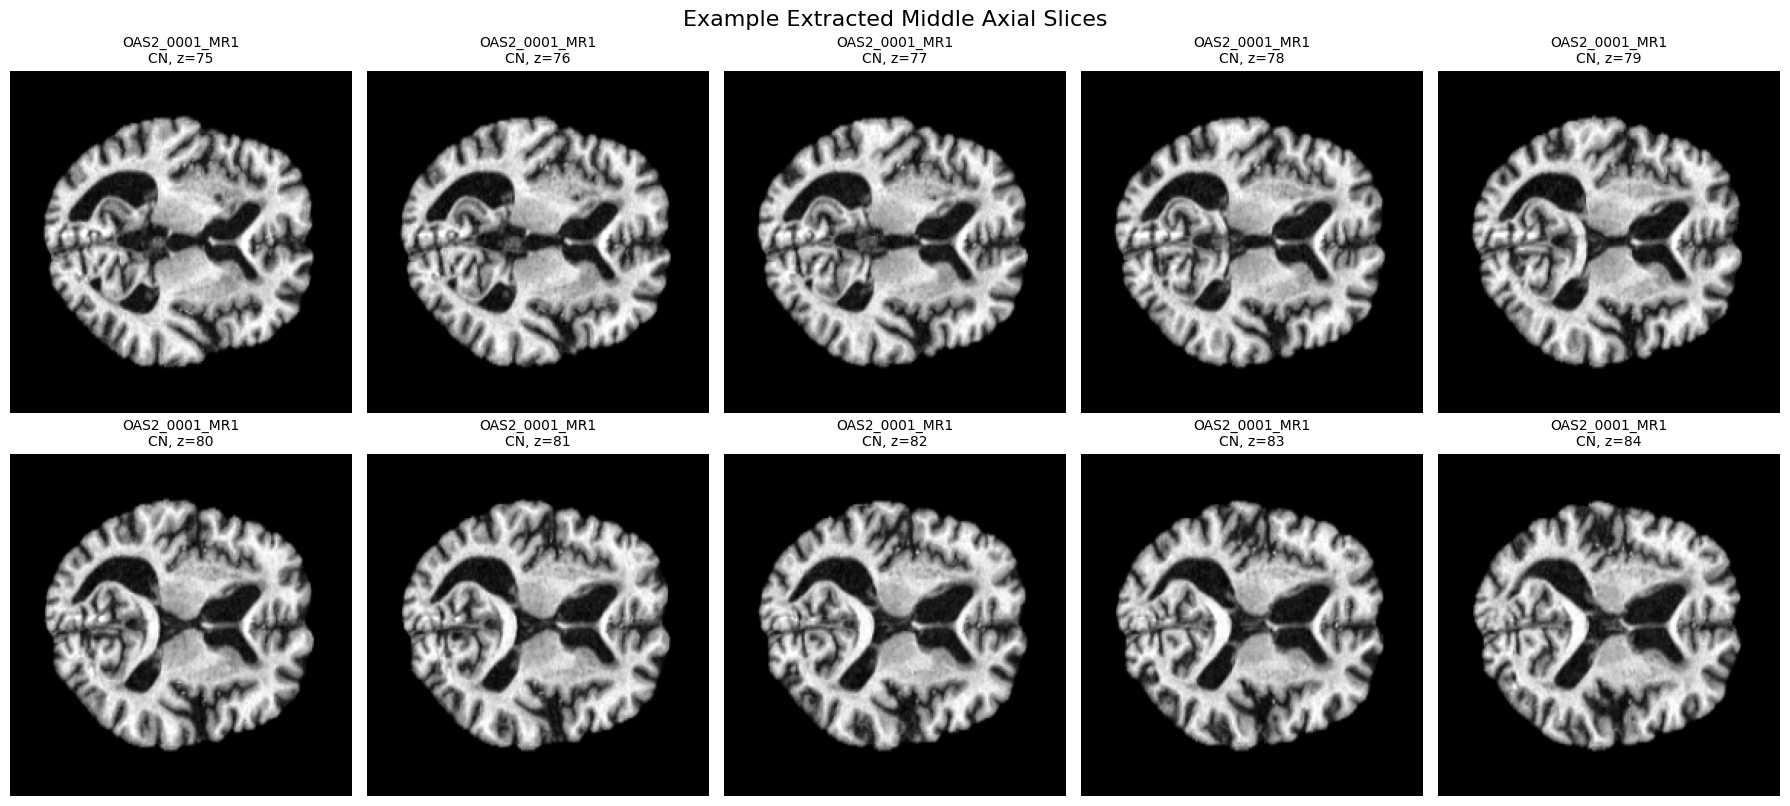

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Define the paths as they were set in Cell 5
SLICES_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local/slices_2d")
METADATA_CSV = SLICES_DIR.parent / "oasis2_slices_metadata.csv"

print(f"Loading slice metadata from: {METADATA_CSV}")

if not METADATA_CSV.exists():
    raise FileNotFoundError(f"Metadata CSV not found at {METADATA_CSV}. Please ensure Cell 5 was run successfully.")

df_slices = pd.read_csv(METADATA_CSV)
print(f"Loaded {len(df_slices)} slice records.")

# Display a few example slices
num_examples_to_plot = 10  # You can change this number

print(f"\nDisplaying {min(num_examples_to_plot, len(df_slices))} example slices...")

fig, axes = plt.subplots(2, 5, figsize=(18, 8)) # 2 rows, 5 columns for 10 examples
axes = axes.flatten()

for i, row in df_slices.head(num_examples_to_plot).iterrows():
    npy_path = Path(row["npy_path"])
    class_label = row["class_label"]
    mri_id = row["mri_id"]
    slice_index = row["slice_index"]

    if not npy_path.exists():
        print(f"Warning: .npy file not found for {npy_path}. Skipping.")
        axes[i].text(0.5, 0.5, "File Not Found", ha='center', va='center', fontsize=10)
        axes[i].axis('off')
        continue

    # Load the 2D slice data
    slice_data = np.load(npy_path)

    axes[i].imshow(slice_data, cmap='gray')
    axes[i].set_title(f"{mri_id}\n{class_label}, z={slice_index}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Example Extracted Middle Axial Slices", fontsize=16, y=1.02)
plt.show()

### Middle Axial Slices of an Alzheimer's (AD) Patient Volume

Found an AD patient MRI ID: OAS2_0007_MR3
Using preprocessed volume: OAS2_0007_MR3_mpr-1.nifti.nii_preproc_final.nii.gz
Loaded AD volume shape: (197, 233, 189)
Showing slices from z = 75 to z = 112 (38 slices)


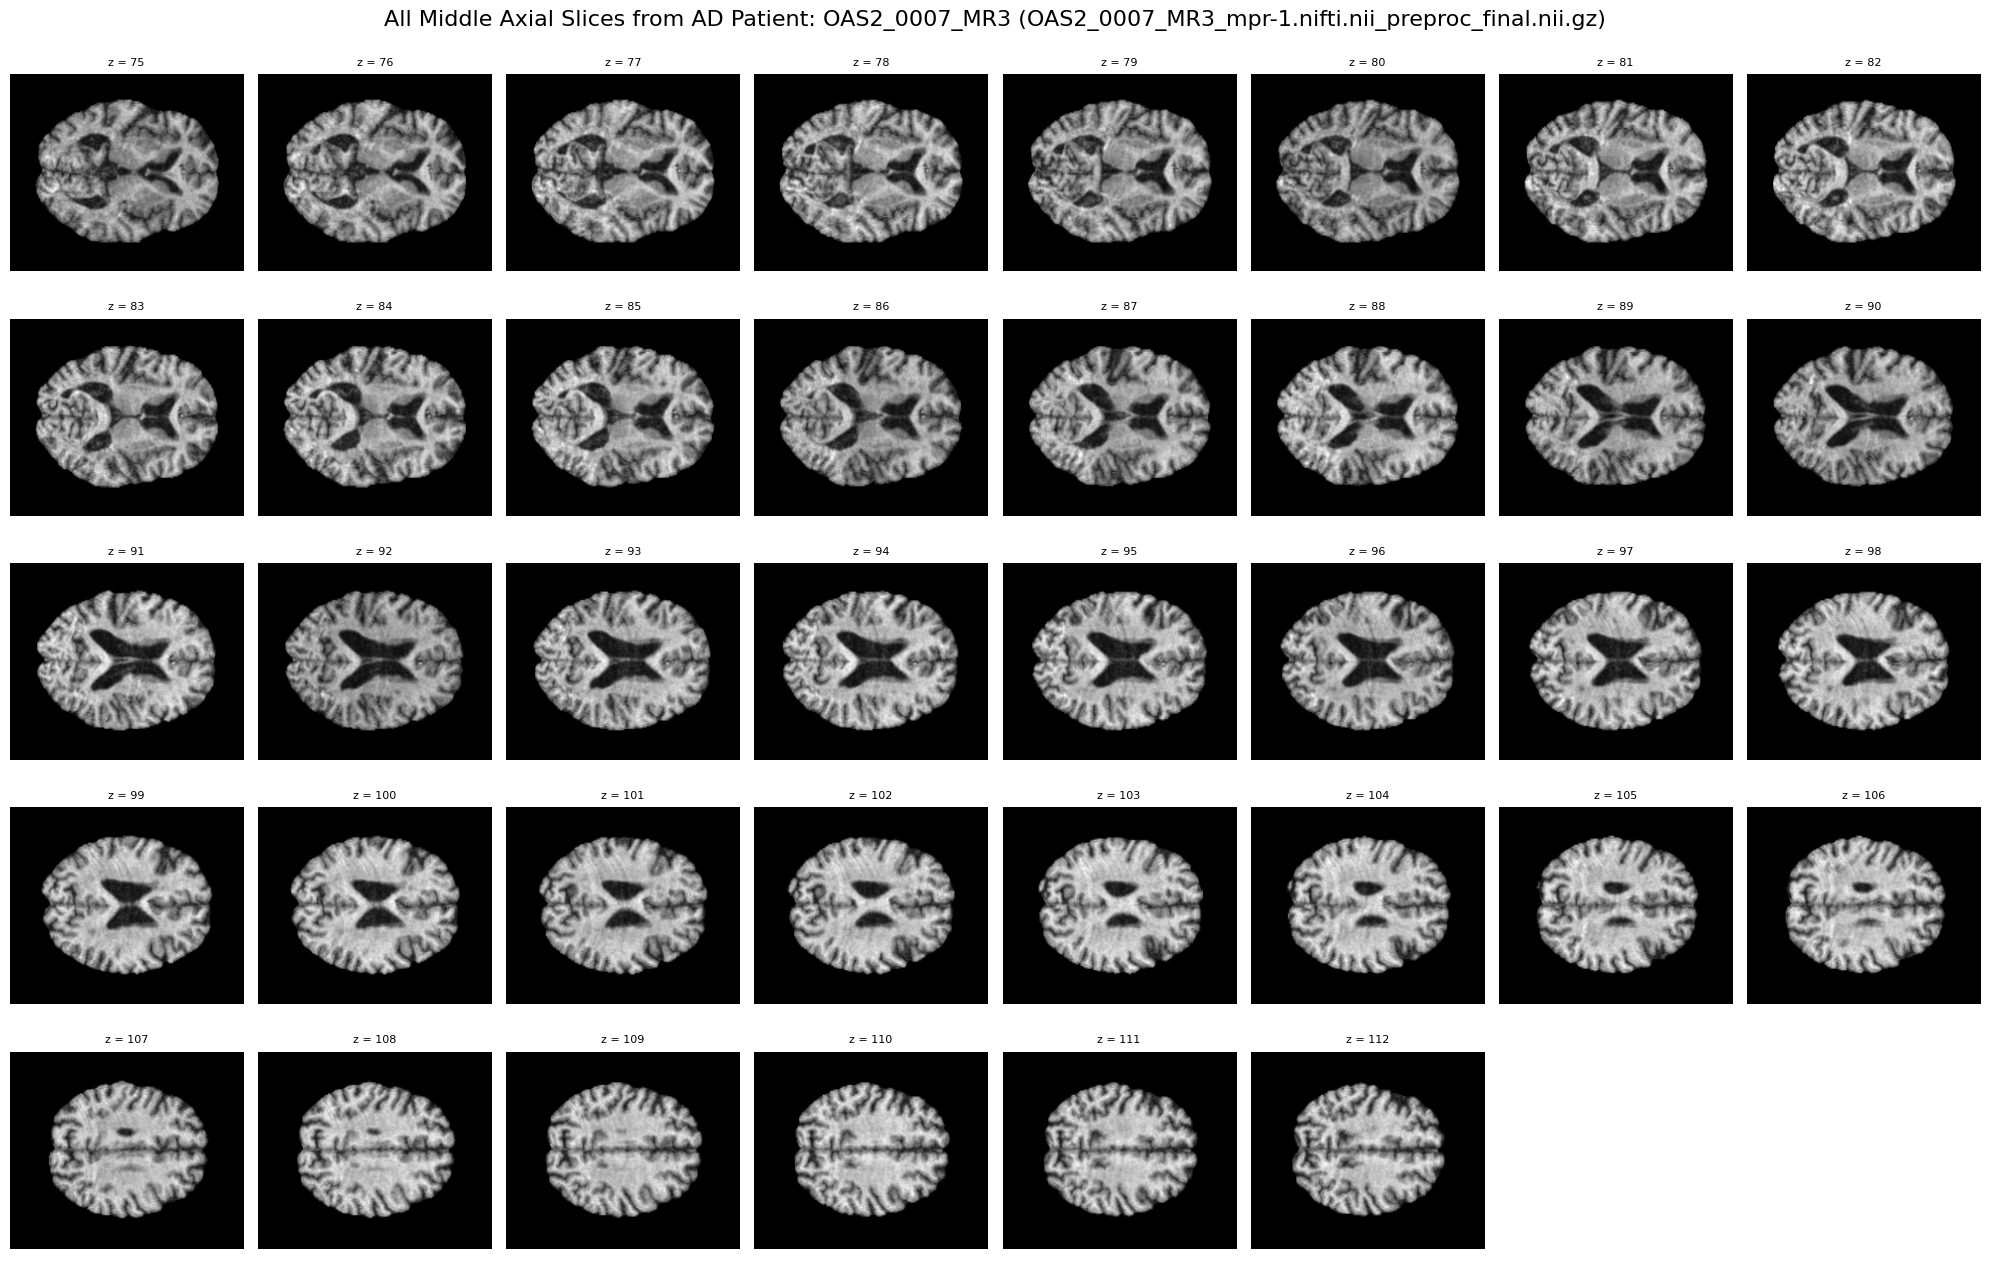

In [10]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Assuming PREPROC_3D_DIR is defined from previous cells (e.g., Cell 0 or Cell 3)
PREPROC_3D_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local/preprocessed_3d")

# Assuming df_slices is available and loaded from Cell 5
if 'df_slices' not in locals():
    print("Loading df_slices from metadata CSV...")
    METADATA_CSV = Path("/content/drive/MyDrive/OASIS2_Project_local/oasis2_slices_metadata.csv")
    if not METADATA_CSV.exists():
        raise FileNotFoundError(f"Metadata CSV not found at {METADATA_CSV}. Please run Cell 5 first.")
    df_slices = pd.read_csv(METADATA_CSV)

# 1. Find an AD patient MRI ID
ad_mri_id = None
# Get unique MRI IDs with 'AD' label
ad_patients_df = df_slices[df_slices['class_label'] == 'AD'].drop_duplicates(subset=['mri_id'])

if not ad_patients_df.empty:
    ad_mri_id = ad_patients_df.iloc[0]['mri_id']
    print(f"Found an AD patient MRI ID: {ad_mri_id}")
else:
    raise ValueError("No 'AD' labeled patients found in df_slices. Please ensure AD samples exist after Cell 5.")

# 2. Construct the path to the corresponding preprocessed 3D volume
# Example filename structure: OAS2_0007_MR3_mpr-1.nifti.nii_preproc_final.nii.gz
# We need to find the full filename for the specific ad_mri_id

# Search for any preprocessed file that starts with the ad_mri_id
ad_volume_paths = list(PREPROC_3D_DIR.glob(f"{ad_mri_id}*_preproc_final.nii.gz"))

if ad_volume_paths:
    volume_path = ad_volume_paths[0] # Pick the first one if multiple exist for an MRI ID
    print(f"Using preprocessed volume: {volume_path.name}")
else:
    raise FileNotFoundError(f"Could not find preprocessed volume for AD patient {ad_mri_id} in {PREPROC_3D_DIR}.")

# 3. Load the 3D volume
img = nib.load(str(volume_path))
data = img.get_fdata().astype(np.float32)

print(f"Loaded AD volume shape: {data.shape}")

# 4. Define middle slice range (40% to 60% of z-axis)
nz = data.shape[2]
start_z = max(0, int(0.40 * nz))
end_z   = min(nz, int(0.60 * nz))

print(f"Showing slices from z = {start_z} to z = {end_z-1} ({end_z - start_z} slices)")

# 5. Display all slices in a grid
n_slices = end_z - start_z
ncols = 8  # Adjust how many slices per row
nrows = int(np.ceil(n_slices / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2.5, nrows*2.5))
axes = axes.flatten()  # make it easy to loop

slice_idx = 0
for z in range(start_z, end_z):
    ax = axes[slice_idx]
    ax.imshow(data[:, :, z], cmap='gray', origin='lower')
    ax.set_title(f"z = {z}", fontsize=8)
    ax.axis('off')
    slice_idx += 1

# Hide empty subplots if any
for i in range(slice_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle(f"All Middle Axial Slices from AD Patient: {ad_mri_id} ({volume_path.name})", fontsize=16, y=1.02)
plt.show()

In [8]:
# Interactive slice viewer (scroll with slider)
from ipywidgets import interact
import matplotlib.pyplot as plt

def show_slice(z):
    plt.figure(figsize=(8, 8))
    plt.imshow(data[:, :, z], cmap='gray', origin='lower')
    plt.title(f"Slice z = {z}")
    plt.axis('off')
    plt.show()

interact(show_slice, z=(start_z, end_z-1))

NameError: name 'start_z' is not defined

# **2D Preprocessing of MRI slices**

preprocessing and train/val/test split

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
from torchvision import transforms
from PIL import Image

print("=== Cell 10: Creating DataLoaders for Model Training ===")

# Paths
SLICES_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local/slices_2d")
METADATA_CSV = SLICES_DIR.parent / "oasis2_slices_metadata.csv"

# Load metadata
df = pd.read_csv(METADATA_CSV)
print(f"Total slices loaded: {len(df)}")
print("Class distribution:\n", df["class_label"].value_counts())

# Encode labels
label_to_idx = {"CN": 0, "MCI": 1, "AD": 2}
df["label"] = df["class_label"].map(label_to_idx)

# Stratified split: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

print(f"Train set: {len(train_df)} slices")
print(f"Val set  : {len(val_df)} slices")
print(f"Test set : {len(test_df)} slices")

# Save splits
train_df.to_csv(SLICES_DIR.parent / "train_metadata.csv", index=False)
val_df.to_csv(SLICES_DIR.parent / "val_metadata.csv", index=False)
test_df.to_csv(SLICES_DIR.parent / "test_metadata.csv", index=False)

print("Splits saved successfully.")

=== Cell 10: Creating DataLoaders for Model Training ===
Total slices loaded: 7942
Class distribution:
 class_label
CN     4522
MCI    2470
AD      950
Name: count, dtype: int64
Train set: 5559 slices
Val set  : 1191 slices
Test set : 1192 slices


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
from torchvision import transforms
from PIL import Image

# Fix: Downgrade numpy for compatibility with sklearn and scipy
!pip install numpy==1.23.5
# NOTE: After running this, please restart your Colab runtime (Runtime -> Restart runtime)

print("=== Cell 10: Creating DataLoaders for Model Training ===")

# Paths
SLICES_DIR = Path("/content/drive/MyDrive/OASIS2_Project_local/slices_2d")
METADATA_CSV = SLICES_DIR.parent / "oasis2_slices_metadata.csv"

# Load metadata
df = pd.read_csv(METADATA_CSV)
print(f"Total slices loaded: {len(df)}")
print("Class distribution:\n", df["class_label"].value_counts())

# Encode labels
label_to_idx = {"CN": 0, "MCI": 1, "AD": 2}
df["label"] = df["class_label"].map(label_to_idx)

# Stratified split: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

print(f"Train set: {len(train_df)} slices")
print(f"Val set  : {len(val_df)} slices")
print(f"Test set : {len(test_df)} slices")

# Save splits
train_df.to_csv(SLICES_DIR.parent / "train_metadata.csv", index=False)
val_df.to_csv(SLICES_DIR.parent / "val_metadata.csv", index=False)
test_df.to_csv(SLICES_DIR.parent / "test_metadata.csv", index=False)

print("Splits saved successfully.")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject